In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')
print(df.tail(15))

     PassengerId  Survived  Pclass  \
876          877         0       3   
877          878         0       3   
878          879         0       3   
879          880         1       1   
880          881         1       2   
881          882         0       3   
882          883         0       3   
883          884         0       2   
884          885         0       3   
885          886         0       3   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                              Name     Sex   Age  SibSp  \
876                  Gustafsson, Mr. Alfred Ossian    male  20.0      0   
877                           Petroff, Mr. Nedelio    male  19.0      0   
878                             Laleff, Mr. Kristo    male   NaN      0   
879  Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)  female  56.0      0   
880   Shelley, M

In [5]:
df_dropped = df.drop(['PassengerId', 'Ticket', 'Name'], axis=1)
print(df_dropped.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S


In [ ]:
df_filled = df_dropped.copy()
fill = {
    'Age': df_filled['Age'].mean(),
    'Embarked': df_filled['Embarked'].mode()[0]
}
df_filled = df_filled.fillna(fill)
print(df_filled.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      0
dtype: int64


In [14]:
df_filled['Age_20_35'] = df_filled['Age'].between(20, 35).astype(int)
df_filled['Age_35_50'] = df_filled['Age'].between(35, 50).astype(int)
df_filled['Age_50_80'] = df_filled['Age'].between(50, 80).astype(int)
print(df_filled[['Age_20_35', 'Age_35_50', 'Age_50_80']].sum())

Age_20_35    510
Age_35_50    171
Age_50_80     74
dtype: int64


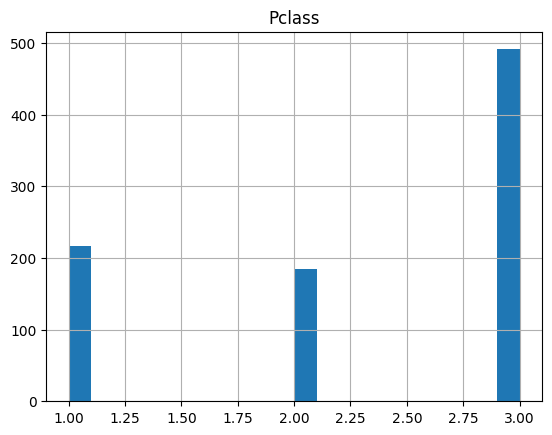

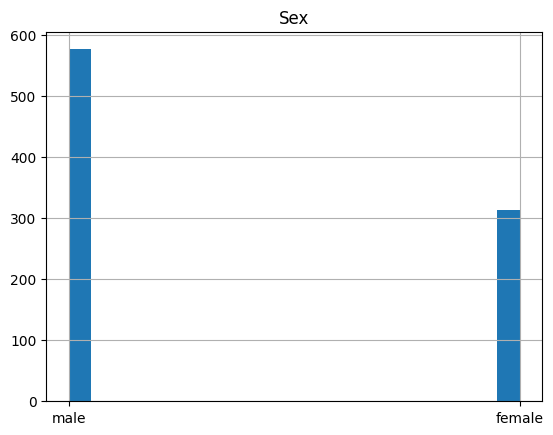

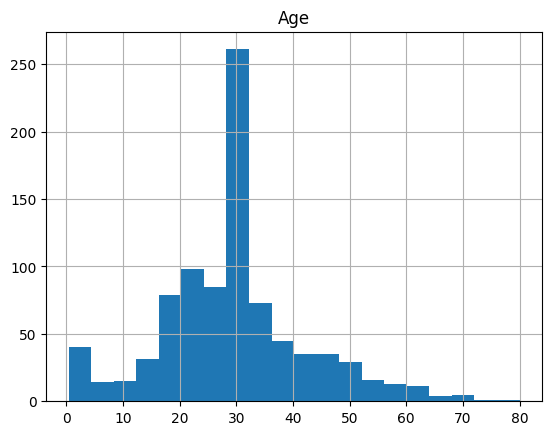

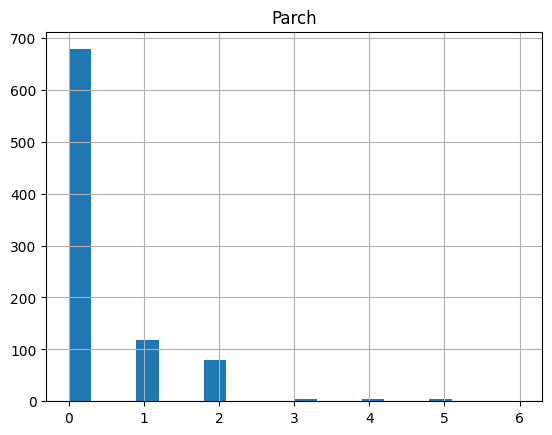

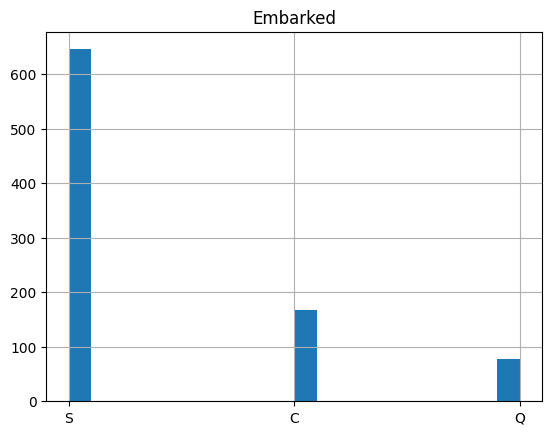

In [12]:
cols_to_plot = ['Pclass', 'Sex', 'Age', 'Parch', 'Embarked']
for col in cols_to_plot:
    if col in df_filled.columns:
        plt.figure()
        df_filled[col].hist(bins=20)
        plt.title(f'{col}')
        plt.show()

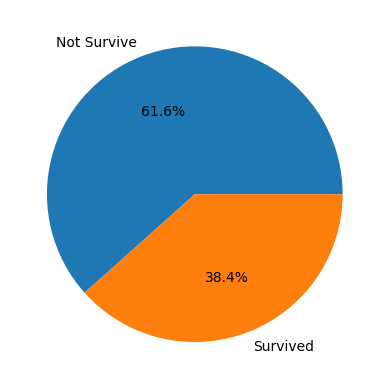

In [13]:
survived_counts = df_filled['Survived'].value_counts()
plt.figure()
plt.pie(survived_counts, labels=['Not Survive', 'Survived'], autopct='%1.1f%%')
plt.show()